In [ ]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Constants
T = 298.15
kB = 8.617e-5
h = 4.135667e-15
kT = kB * T
log_prefactor = np.log(kT / h)

# 1. Generate Fake Data
P_vals = [0.001, 0.01, 0.1, 1.0]
C_vals = [0.1, 0.25, 0.5, 1.0]
P_grid, C_grid = np.meshgrid(P_vals, C_vals)
P_grid, C_grid = P_grid.ravel(), C_grid.ravel()

# Precompute logs for speed
log_P = np.log(P_grid)
log_C = np.log(C_grid)

dG1_true, dG2_true, dGact_true = -0.15, -0.04, 0.8

K1_true = np.exp(-dG1_true / kT)
K2_true = np.exp(-dG2_true / kT)
k_true = np.exp(log_prefactor - dGact_true / kT)

denom_true = 1 + K1_true * P_grid + K2_true * C_grid

theta_CO_exp = (K1_true * P_grid) / denom_true 
theta_OH_exp = (K2_true * C_grid) / denom_true 
log_rate_exp = np.log((k_true * C_grid * K1_true * P_grid) / denom_true)

In [ ]:
# 2. Fit 1: Thetas
with pm.Model() as model_thetas:
    dG1 = pm.Uniform('dG1', lower=-2, upper=0.1)
    dG2 = pm.Uniform('dG2', lower=-2, upper=0.1)
    sigma = 0.33
    
    log_term1 = log_P - dG1 / kT
    log_term2 = log_C - dG2 / kT
    
    # logaddexp(0, x) is equivalent to log(1 + exp(x))
    log_denom = pm.math.logaddexp(0, pm.math.logaddexp(log_term1, log_term2))
    
    pm.Normal('obs_CO', mu=pm.math.exp(log_term1 - log_denom), sigma=sigma, observed=theta_CO_exp)
    pm.Normal('obs_OH', mu=pm.math.exp(log_term2 - log_denom), sigma=sigma, observed=theta_OH_exp)
    
    trace_thetas = pm.sample(1000, tune=1000, return_inferencedata=True, progressbar=True, target_accept=0.95, chains=2, cores=2)

In [ ]:
# 3. Fit 2: Rate
with pm.Model() as model_rate:
    dG1 = pm.Uniform('dG1', lower=-2, upper=0.1)
    dG2 = pm.Uniform('dG2', lower=-2, upper=0.1)
    dGact = pm.Uniform('dGact', lower=0, upper=2)
    sigma = 1
    
    log_term1 = log_P - dG1 / kT
    log_term2 = log_C - dG2 / kT
    log_denom = pm.math.logaddexp(0, pm.math.logaddexp(log_term1, log_term2))
    
    log_k = log_prefactor - dGact / kT
    mu_log_rate = log_k + log_C + log_term1 - log_denom
    
    pm.Normal('obs_rate', mu=mu_log_rate, sigma=sigma, observed=log_rate_exp)
    
    trace_rate = pm.sample(1000, tune=1000, return_inferencedata=True, progressbar=True, target_accept=0.95, chains=2, cores=2)

In [ ]:
print("\n--- Fit 1: Thetas Summary ---")
print(az.summary(trace_thetas, var_names=['dG1', 'dG2']))

print("\n--- Fit 2: Rate Summary ---")
print(az.summary(trace_rate, var_names=['dG1', 'dG2', 'dGact']))

az.plot_posterior(trace_thetas, var_names=['dG1', 'dG2'])
plt.show()

az.plot_posterior(trace_rate, var_names=['dG1', 'dG2', 'dGact'])
plt.show()

In [ ]:
# 5. Plotter
def plot_mixed_model_vs_exp(dGact_val, dG1_val, dG2_val):
    log_t1 = log_P - dG1_val / kT
    log_t2 = log_C - dG2_val / kT
    log_den = np.logaddexp(0, np.logaddexp(log_t1, log_t2))
    
    th_CO_mod = np.exp(log_t1 - log_den)
    th_OH_mod = np.exp(log_t2 - log_den)
    log_rate_mod = (log_prefactor - dGact_val / kT) + log_C + log_t1 - log_den
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    
    axes[0].scatter(th_CO_mod, theta_CO_exp, c='b')
    axes[0].set_title(r"Linear $\theta_{CO}$")
    
    axes[1].scatter(th_OH_mod, theta_OH_exp, c='g')
    axes[1].set_title(r"Linear $\theta_{OH}$")
    
    axes[2].scatter(log_rate_mod, log_rate_exp, c='r')
    axes[2].set_title("log(Rate) - TST")
    
    for ax in axes:
        lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
        ax.plot(lims, lims, 'k--', alpha=0.5, zorder=0)
        ax.set_xlabel("Model")
        ax.set_ylabel("Experimental")
        
    plt.tight_layout()
    plt.show()

plot_mixed_model_vs_exp(0.8, -1, -0.9)

# Fake data

In [42]:
import numpy as np

# Constants
kb_eV, kb_J, h, T = 8.617e-5, 1.38e-23, 6.626e-34, 298.15
R, F = 8.314, 96485.3

# Grids and Conditions
E_in = np.linspace(-0.2, 0.2, 100)
dE = E_in[1] - E_in[0]
# Sequence: [0] low P low C, [1] low P high C, [2] high P low C, [3] high P high C
conditions = [(0.01, 0.1), (0.01, 1.0), (1.0, 0.1), (1.0, 1.0)] 
C_KOH_list = np.array([0.1, 1.0])
P_CO_list = np.array([0.01, 1.0])

# True Parameters
deltaG1_0_true = -0.15
deltaG4_0_true = -0.04
beta_2_true = 0.5
Gact2_0_true = 0.8

# ==========================================
# Flooding Model Configuration
# ==========================================
flooding_type = 'step' # Options: 'linear', 'step', 'smooth', 'bubble', 'persistent'
area_loss_fraction = 0.9     # Max area lost across an entire setup's lifetime

E_norm = (E_in - E_in[0]) / (E_in[-1] - E_in[0]) 

if flooding_type == 'step':
    step_center = np.random.uniform(0.2, 0.8)
    steepness = np.random.uniform(50, 150)
    sigmoid = 1.0 / (1.0 + np.exp(-steepness * (E_norm - step_center)))
elif flooding_type == 'smooth':
    power = np.random.uniform(2.5, 5.0)
# ==========================================

# Pass 1: Generate pristine kinetics
fake_rate = np.zeros((4, 100))
for i, (p_co, c_oh) in enumerate(conditions):
    deltaG4 = deltaG4_0_true - E_in
    Gact2 = Gact2_0_true - beta_2_true * E_in
    
    log_K1 = -deltaG1_0_true / (kb_eV * T)
    log_K4 = -deltaG4 / (kb_eV * T)
    log_k2 = np.log(kb_J * T / h) - Gact2 / (kb_eV * T)
    
    term_CO = log_K1 + np.log(p_co)
    term_OH = log_K4 + np.log(c_oh)
    log_theta_free = -np.log(1 + np.exp(term_CO) + np.exp(term_OH))
    log_theta_CO = term_CO + log_theta_free
    
    fake_rate[i] = np.exp(log_k2 + log_theta_CO + np.log(c_oh))

# Pass 2: Apply chosen flooding model 
fake_current = np.zeros((4, 100))

if flooding_type == 'bubble':
    max_accumulated = np.max(np.cumsum(fake_rate, axis=1))
elif flooding_type == 'persistent':
    # Link the setups: Setup 1 (0.1 M KOH) = idx 0 then idx 2. Setup 2 (1.0 M KOH) = idx 1 then idx 3.
    total_bubbles_setup1 = np.sum(fake_rate[0]) + np.sum(fake_rate[2])
    total_bubbles_setup2 = np.sum(fake_rate[1]) + np.sum(fake_rate[3])
    max_accumulated = max(total_bubbles_setup1, total_bubbles_setup2)

for i, (p_co, c_oh) in enumerate(conditions):
    
    if flooding_type == 'linear':
        area_array = 1000 * (1.0 - area_loss_fraction * E_norm)
    elif flooding_type == 'step':
        area_array = 1000 * (1.0 - area_loss_fraction * sigmoid)
    elif flooding_type == 'smooth':
        area_array = 1000 * (1.0 - area_loss_fraction * (E_norm ** power))
    elif flooding_type == 'bubble':
        accumulated_bubbles = np.cumsum(fake_rate[i])
        area_array = 1000 * (1.0 - area_loss_fraction * (accumulated_bubbles / max_accumulated))
    elif flooding_type == 'persistent':
        # Figure out the starting damage based on the sequence
        prior_bubbles = 0.0
        if i == 2: # Second run for 0.1 M KOH (inherits damage from idx 0)
            prior_bubbles = np.sum(fake_rate[0])
        elif i == 3: # Second run for 1.0 M KOH (inherits damage from idx 1)
            prior_bubbles = np.sum(fake_rate[1])
            
        current_accumulated = prior_bubbles + np.cumsum(fake_rate[i])
        area_array = 1000 * (1.0 - area_loss_fraction * (current_accumulated / max_accumulated))

    # Experimental Current (Flooded Area + Noisy)
    current = fake_rate[i] * area_array
    noise = np.random.normal(0, 0.05 * current)
    fake_current[i] = current + noise

# Experimental Rate
rate_obs = fake_current / 1000

# Function to map 1D arrays to 3D and calc KOs
def calculate_KOs_numpy(rate_1d):
    rate_3d = np.zeros((2, 2, 100))
    rate_3d[0, 0, :] = rate_1d[0] # P=0.01, C=0.1
    rate_3d[1, 0, :] = rate_1d[1] # P=0.01, C=1.0
    rate_3d[0, 1, :] = rate_1d[2] # P=1.0, C=0.1
    rate_3d[1, 1, :] = rate_1d[3] # P=1.0, C=1.0
    
    log_rate = np.log(rate_3d)
    
    d_log_rate_dE = np.zeros_like(log_rate)
    d_log_rate_dE[:, :, 1:-1] = (log_rate[:, :, 2:] - log_rate[:, :, :-2]) / (2 * dE)
    d_log_rate_dE[:, :, 0] = (log_rate[:, :, 1] - log_rate[:, :, 0]) / dE
    d_log_rate_dE[:, :, -1] = (log_rate[:, :, -1] - log_rate[:, :, -2]) / dE
    alpha = (R * T / F) * d_log_rate_dE
    
    ln_C = np.log(C_KOH_list)
    w_C = (ln_C - np.mean(ln_C)) / np.sum((ln_C - np.mean(ln_C))**2)
    delta_OH = np.sum(w_C[:, None, None] * log_rate, axis=0)
    
    d_ln_P = np.log(P_CO_list[1]) - np.log(P_CO_list[0])
    delta_CO = (log_rate[:, 1:, :] - log_rate[:, :-1, :]) / d_ln_P
    
    return alpha, delta_OH, delta_CO

alpha_act, delta_OH_act, delta_CO_act = calculate_KOs_numpy(fake_rate)
alpha_obs, delta_OH_obs, delta_CO_obs = calculate_KOs_numpy(rate_obs)

# Rate Fitting

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,47,0.12,15
,2000,0,0.50,7


--- Log Rate Fit Posteriors ---
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
deltaG1_0 -0.833  0.706  -1.615   -0.118      0.496    0.012       3.0   
deltaG4_0 -0.700  0.708  -1.484    0.019      0.498    0.012       3.0   
beta_2     0.264  0.018   0.236    0.295      0.011    0.000       3.0   
Gact2_0    0.848  0.002   0.845    0.851      0.001    0.000       3.0   
sigma      0.519  0.022   0.478    0.559      0.011    0.001       4.0   

           ess_tail  r_hat  
deltaG1_0      21.0   1.94  
deltaG4_0      22.0   1.94  
beta_2         93.0   1.79  
Gact2_0        78.0   1.75  
sigma          83.0   1.41  


array([[<Axes: title={'center': 'deltaG1_0'}>,
        <Axes: title={'center': 'deltaG4_0'}>,
        <Axes: title={'center': 'beta_2'}>],
       [<Axes: title={'center': 'Gact2_0'}>,
        <Axes: title={'center': 'sigma'}>, <Axes: >]], dtype=object)

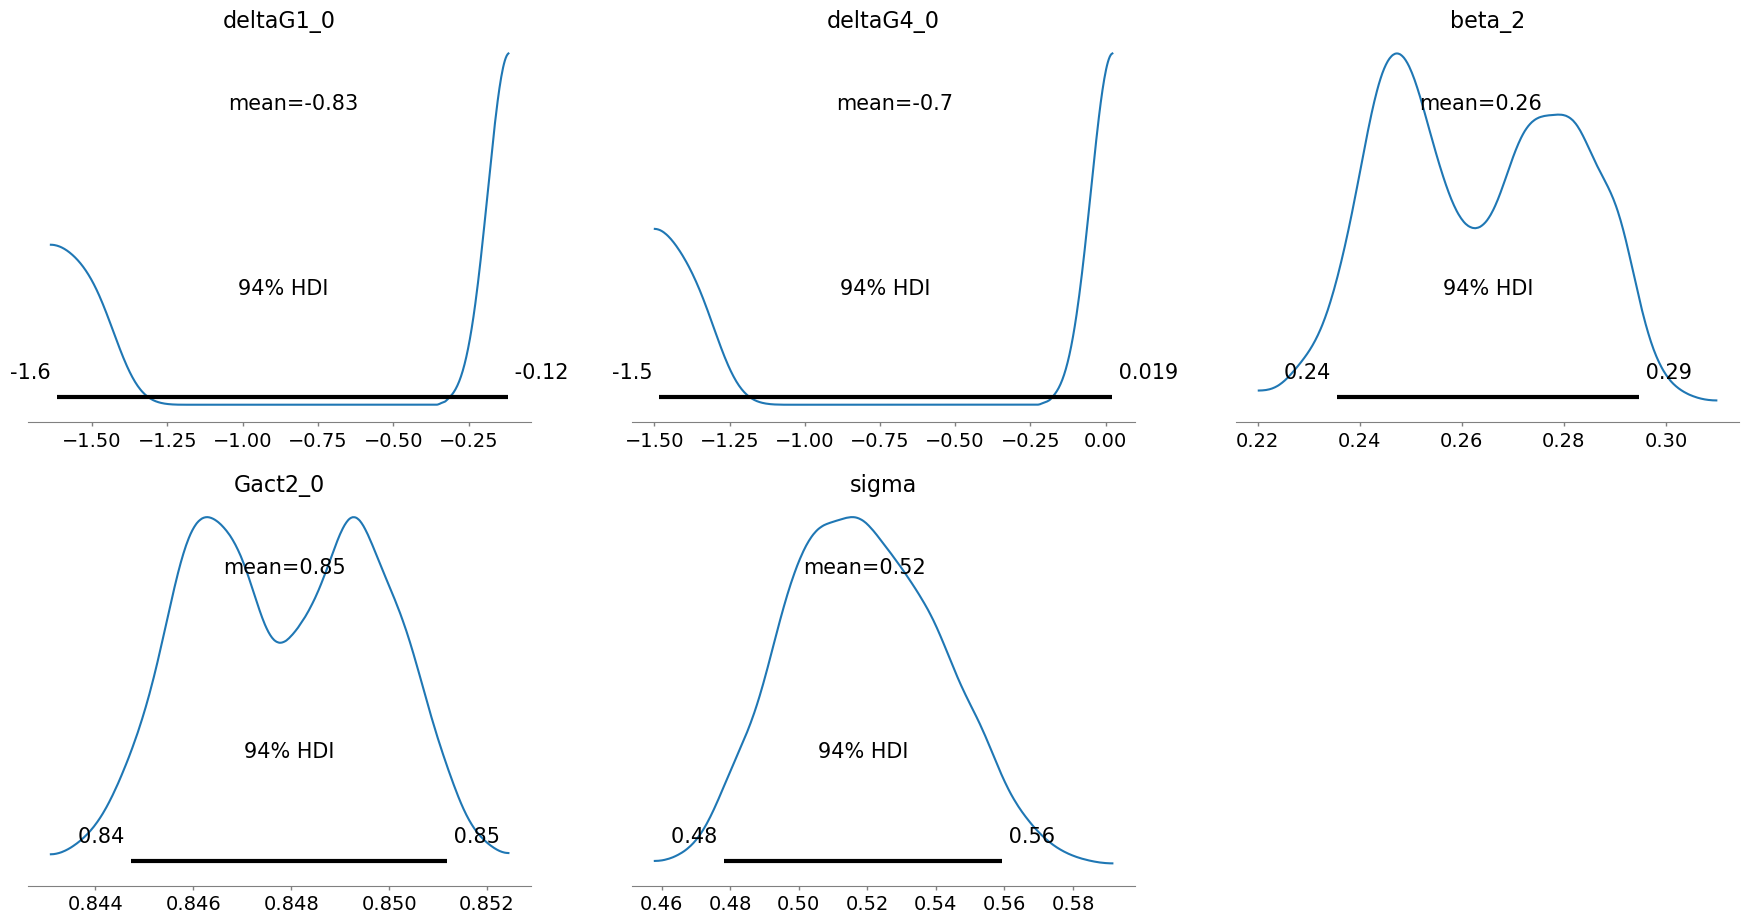

In [43]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import nutpie

P_CO_arr = np.array([c[0] for c in conditions])[:, None]
C_OH_arr = np.array([c[1] for c in conditions])[:, None]

with pm.Model() as ER_Rate:
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5)
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)     
    Gact2_0 = pm.Uniform('Gact2_0', lower=0, upper=2)
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2 * E_in
    log_K1 = -deltaG1_0 / (kb_eV * T)
    log_K4 = -deltaG4 / (kb_eV * T)
    log_k2 = np.log(kb_J * T / h) - Gact2 / (kb_eV * T)

    P_CO_pt = pt.as_tensor_variable(P_CO_arr)
    C_OH_pt = pt.as_tensor_variable(C_OH_arr)

    term_CO = log_K1 + pt.log(P_CO_pt)
    term_OH = log_K4 + pt.log(C_OH_pt)
    zeros = pt.zeros_like(term_OH)
    log_theta = -pm.math.logsumexp(pt.stack([zeros, term_CO + zeros, term_OH + zeros]), axis=0)
    log_theta_CO = term_CO + log_theta

    log_rate_mu = log_k2 + log_theta_CO + pt.log(C_OH_pt)
    pm.Normal('obs', mu=log_rate_mu, sigma=sigma, observed=np.log(rate_obs))

compiled_model_rate = nutpie.compile_pymc_model(ER_Rate)
trace_ER_Rate = nutpie.sample(compiled_model_rate, draws=1000, tune=1000, chains=2)

print("--- Log Rate Fit Posteriors ---")
my_vars_rate = ['deltaG1_0', 'deltaG4_0', 'beta_2', 'Gact2_0', 'sigma']
print(az.summary(trace_ER_Rate, var_names=my_vars_rate))
az.plot_posterior(trace_ER_Rate, var_names=my_vars_rate)

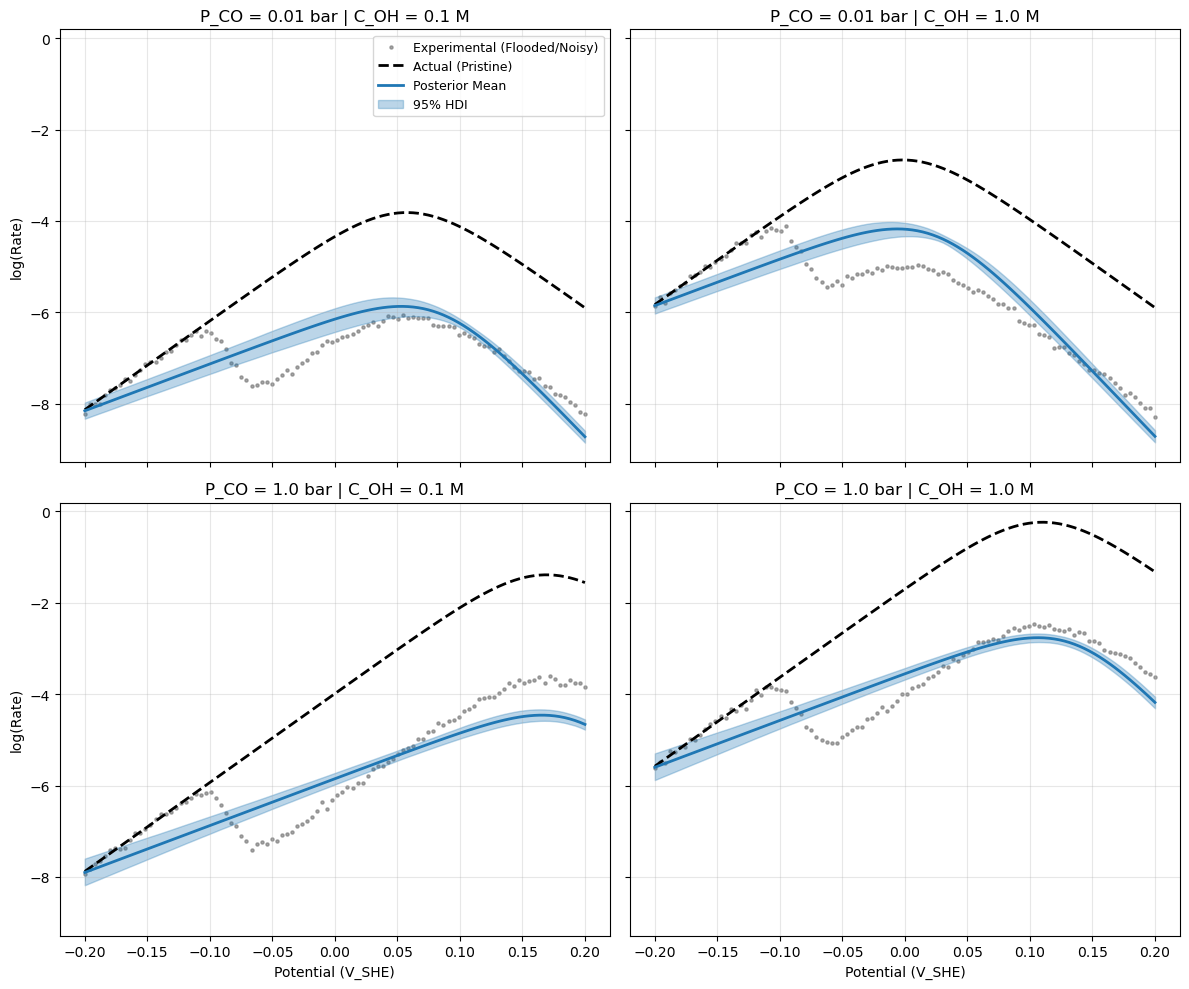

In [44]:
import matplotlib.pyplot as plt

post = trace_ER_Rate.posterior
g1_samples = post['deltaG1_0'].values.flatten()
g4_samples = post['deltaG4_0'].values.flatten()
beta_samples = post['beta_2'].values.flatten()
gact_samples = post['Gact2_0'].values.flatten()

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, (p_co, c_oh) in enumerate(conditions):
    E_mesh = E_in[None, :] 
    dg4 = g4_samples[:, None] - E_mesh
    gact = gact_samples[:, None] - beta_samples[:, None] * E_mesh

    lk1 = -g1_samples[:, None] / (kb_eV * T)
    lk4 = -dg4 / (kb_eV * T)
    lk2 = np.log(kb_J * T / h) - gact / (kb_eV * T)

    t_co = lk1 + np.log(p_co)
    t_oh = lk4 + np.log(c_oh)

    l_theta_free = -np.log(1 + np.exp(t_co) + np.exp(t_oh))
    l_theta_CO = t_co + l_theta_free

    log_rate_samples = lk2 + l_theta_CO + np.log(c_oh)
    log_rate_mean = np.mean(log_rate_samples, axis=0)
    log_hdi = np.percentile(log_rate_samples, [2.5, 97.5], axis=0)

    ax = axes[i]
    ax.scatter(E_in, np.log(rate_obs[i]), s=5, color='gray', alpha=0.7, label='Experimental (Flooded/Noisy)')
    ax.plot(E_in, np.log(fake_rate[i]), 'k--', lw=2, label='Actual (Pristine)')
    ax.plot(E_in, log_rate_mean, color='tab:blue', lw=2, label='Posterior Mean')
    ax.fill_between(E_in, log_hdi[0], log_hdi[1], color='tab:blue', alpha=0.3, label='95% HDI')
    
    ax.set_title(f'P_CO = {p_co} bar | C_OH = {c_oh} M')
    ax.grid(alpha=0.3)
    if i >= 2: ax.set_xlabel('Potential (V_SHE)')
    if i % 2 == 0: ax.set_ylabel('log(Rate)')

axes[0].legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

# KO Fitting

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.53,15
,2000,28,0.12,35



--- KO Fit Posteriors ---
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
deltaG1_0 -0.764  0.617  -1.515   -0.132      0.432    0.011       3.0   
deltaG4_0 -0.650  0.616  -1.402   -0.019      0.432    0.011       3.0   
beta_2     0.353  0.017   0.319    0.381      0.002    0.000      69.0   
sigma      0.162  0.004   0.155    0.170      0.000    0.000     200.0   

           ess_tail  r_hat  
deltaG1_0      89.0   1.86  
deltaG4_0      91.0   1.86  
beta_2        479.0   1.03  
sigma         501.0   1.02  


array([<Axes: title={'center': 'deltaG1_0'}>,
       <Axes: title={'center': 'deltaG4_0'}>,
       <Axes: title={'center': 'beta_2'}>,
       <Axes: title={'center': 'sigma'}>], dtype=object)

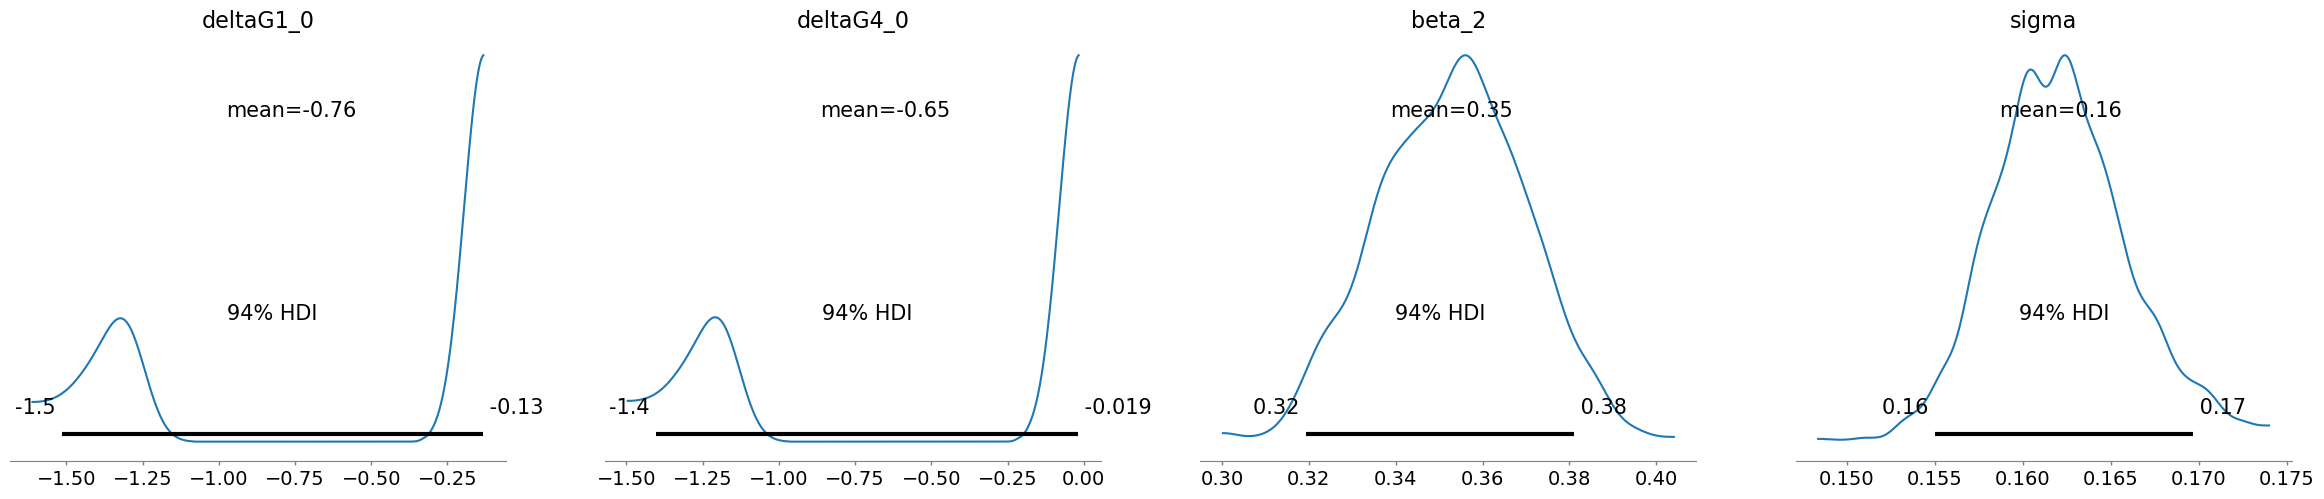

In [45]:
# Setup 3D tensors for KO math
C_KOH_in = C_KOH_list[:, None, None]
P_CO_in = P_CO_list[None, :, None]
E_pt_in = E_in[None, None, :]

ln_C = np.log(C_KOH_list)
w_C_in = ((ln_C - np.mean(ln_C)) / np.sum((ln_C - np.mean(ln_C))**2))[:, None, None]
d_ln_P_CO = np.log(P_CO_list[1]) - np.log(P_CO_list[0])

def calc_observables(log_rate): 
    d_log_rate_dE = pt.zeros_like(log_rate)
    d_log_rate_center_dE = (log_rate[:, :, 2:] - log_rate[:, :, :-2]) / (2*dE)
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 1:-1], d_log_rate_center_dE)
    d_log_rate_start_dE = (log_rate[:, :, 1] - log_rate[:, :, 0]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, 0], d_log_rate_start_dE)
    d_log_rate_end_dE = (log_rate[:, :, -1] - log_rate[:, :, -2]) / dE
    d_log_rate_dE = pt.set_subtensor(d_log_rate_dE[:, :, -1], d_log_rate_end_dE)
    mu_alpha = (R*T/F) * d_log_rate_dE

    mu_delta_OH = pm.math.sum(w_C_in * log_rate, axis=0)
    mu_delta_CO = (log_rate[:, 1:, :] - log_rate[:, :-1, :]) / d_ln_P_CO
    return mu_alpha, mu_delta_OH, mu_delta_CO

with pm.Model() as ER_KO:
    deltaG1_0 = pm.Uniform('deltaG1_0', lower=-2, upper=0.1) 
    deltaG4_0 = pm.Uniform('deltaG4_0', lower=-1.5, upper=0.5)
    beta_2 = pm.Uniform('beta_2', lower=0.05, upper=0.95)      
    Gact2_0 = 0 # Fixed
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    deltaG4 = deltaG4_0 - E_pt_in
    Gact2 = Gact2_0 - beta_2 * E_pt_in
    
    log_K1 = -deltaG1_0 / (kb_eV * T)
    log_k2 = np.log(kb_J * T / h) - Gact2 / (kb_eV * T)
    log_K4 = -deltaG4 / (kb_eV * T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO + term_OH)
    log_theta = -pm.math.logsumexp(pt.stack([zeros, term_CO+zeros, term_OH+zeros]), axis=0)
    log_theta_CO = term_CO + log_theta

    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    mu_alpha, mu_delta_OH, mu_delta_CO = calc_observables(log_rate)

    pm.Normal('obs_alpha', mu=mu_alpha, sigma=2*sigma, observed=alpha_obs)
    pm.Normal('obs_delta_OH', mu=mu_delta_OH, sigma=sigma, observed=delta_OH_obs)
    pm.Normal('obs_delta_CO', mu=mu_delta_CO, sigma=sigma, observed=delta_CO_obs)

compiled_model_ko = nutpie.compile_pymc_model(ER_KO)
trace_ER_KO = nutpie.sample(compiled_model_ko, draws=1000, tune=1000, chains=2)

print("\n--- KO Fit Posteriors ---")
my_vars_ko = ['deltaG1_0', 'deltaG4_0', 'beta_2', 'sigma']
print(az.summary(trace_ER_KO, var_names=my_vars_ko))
az.plot_posterior(trace_ER_KO, var_names=my_vars_ko)

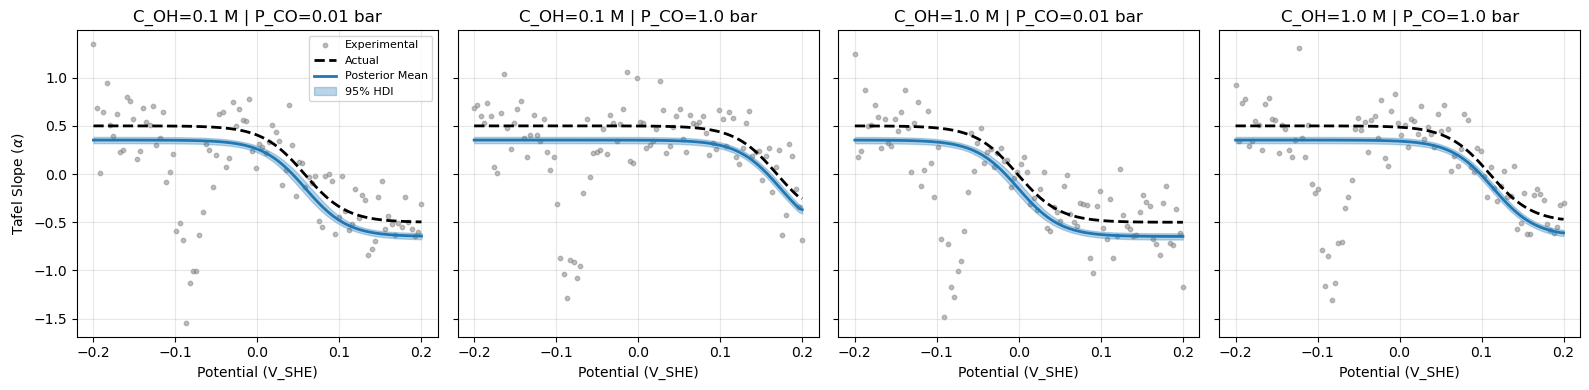

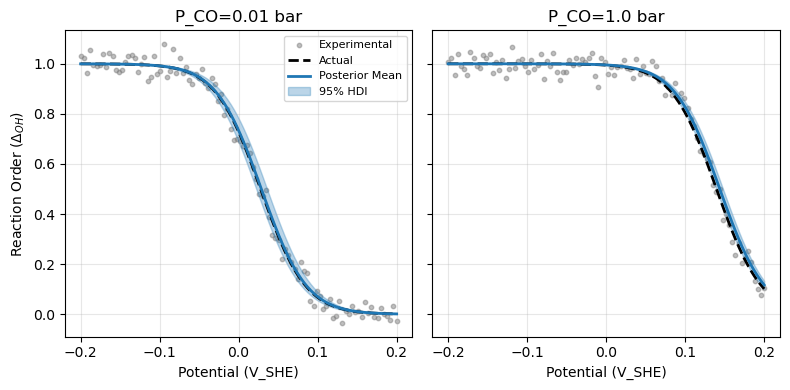

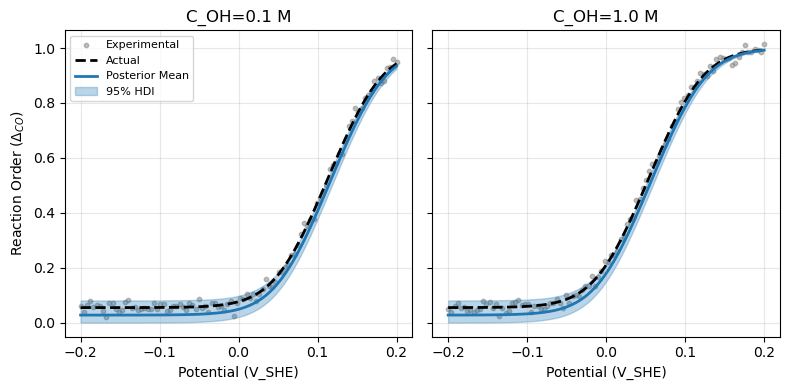

In [46]:
post = trace_ER_KO.posterior
g1_samples = post['deltaG1_0'].values.flatten()
g4_samples = post['deltaG4_0'].values.flatten()
beta_samples = post['beta_2'].values.flatten()

E_mesh = E_in[None, None, None, :]
C_OH_mesh = C_KOH_list[None, :, None, None]
P_CO_mesh = P_CO_list[None, None, :, None]

lk1 = -g1_samples[:, None, None, None] / (kb_eV * T)
dg4 = g4_samples[:, None, None, None] - E_mesh
lk4 = -dg4 / (kb_eV * T)
gact = 0.0 - beta_samples[:, None, None, None] * E_mesh
lk2 = np.log(kb_J * T / h) - gact / (kb_eV * T)

t_co = lk1 + np.log(P_CO_mesh)
t_oh = lk4 + np.log(C_OH_mesh)
l_theta_free = -np.log(1 + np.exp(t_co) + np.exp(t_oh))
l_theta_CO = t_co + l_theta_free

log_rate_samples = lk2 + l_theta_CO + np.log(C_OH_mesh)

# Compute Samples KOs
d_log_rate_dE_samp = np.zeros_like(log_rate_samples)
d_log_rate_dE_samp[:, :, :, 1:-1] = (log_rate_samples[:, :, :, 2:] - log_rate_samples[:, :, :, :-2]) / (2 * dE)
d_log_rate_dE_samp[:, :, :, 0] = (log_rate_samples[:, :, :, 1] - log_rate_samples[:, :, :, 0]) / dE
d_log_rate_dE_samp[:, :, :, -1] = (log_rate_samples[:, :, :, -1] - log_rate_samples[:, :, :, -2]) / dE
alpha_samples = (R * T / F) * d_log_rate_dE_samp

w_C_mesh = w_C_in[None, :, :, :]
delta_OH_samples = np.sum(w_C_mesh * log_rate_samples, axis=1)
delta_CO_samples = (log_rate_samples[:, :, 1:, :] - log_rate_samples[:, :, :-1, :]) / d_ln_P_CO

def plot_observable(obs_data, act_data, pred_samples, titles, ylabel):
    mean_pred = np.mean(pred_samples, axis=0)
    hdi_pred = np.percentile(pred_samples, [2.5, 97.5], axis=0)
    
    if obs_data.ndim == 3: 
        obs_flat, act_flat = obs_data.reshape(-1, len(E_in)), act_data.reshape(-1, len(E_in))
        mean_flat = mean_pred.reshape(-1, len(E_in))
        hdi_low, hdi_high = hdi_pred[0].reshape(-1, len(E_in)), hdi_pred[1].reshape(-1, len(E_in))
    else: 
        obs_flat, act_flat = obs_data, act_data
        mean_flat = mean_pred
        hdi_low, hdi_high = hdi_pred[0], hdi_pred[1]
        
    n_plots = len(titles)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4), sharey=True)
    if n_plots == 1: axes = [axes]
    else: axes = axes.flatten()
    
    for idx in range(n_plots):
        ax = axes[idx]
        ax.scatter(E_in, obs_flat[idx], s=10, color='gray', alpha=0.5, label='Experimental')
        ax.plot(E_in, act_flat[idx], 'k--', lw=2, label='Actual')
        ax.plot(E_in, mean_flat[idx], 'tab:blue', lw=2, label='Posterior Mean')
        ax.fill_between(E_in, hdi_low[idx], hdi_high[idx], color='tab:blue', alpha=0.3, label='95% HDI')
        
        ax.set_title(titles[idx])
        ax.set_xlabel('Potential (V_SHE)')
        if idx == 0: ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

alpha_titles = [f"C_OH={C} M | P_CO={P} bar" for C in C_KOH_list for P in P_CO_list]
plot_observable(alpha_obs, alpha_act, alpha_samples, alpha_titles, r'Tafel Slope ($\alpha$)')

OH_titles = [f"P_CO={P} bar" for P in P_CO_list]
plot_observable(delta_OH_obs, delta_OH_act, delta_OH_samples, OH_titles, r'Reaction Order ($\Delta_{OH}$)')

CO_titles = [f"C_OH={C} M" for C in C_KOH_list]
plot_observable(delta_CO_obs[:, 0, :], delta_CO_act[:, 0, :], delta_CO_samples[:, :, 0, :], CO_titles, r'Reaction Order ($\Delta_{CO}$)')